In [41]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [42]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [44]:
train_images[0].shape


(28, 28, 1)

In [43]:
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

print(f"Reshaped Training images shape: {train_images.shape}")
print(f"Reshaped Test images shape: {test_images.shape}")

Reshaped Training images shape: (60000, 28, 28, 1)
Reshaped Test images shape: (10000, 28, 28, 1)


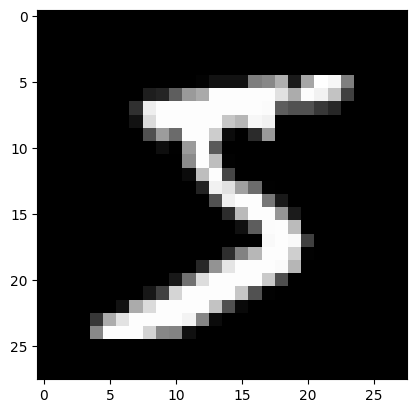

In [45]:
plt.imshow(train_images[0], cmap='gray')
plt.show()

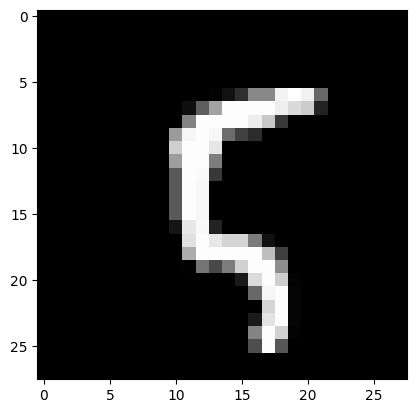

In [46]:
plt.imshow(train_images[100], cmap='gray')
plt.show()

In [47]:
train_images, test_images = train_images / 255.0, test_images / 255.0

In [48]:
train_images[0].shape

(28, 28, 1)

In [49]:
model=models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.add(layers.Flatten())
model.add(layers.Dense(10, activation='softmax'))


In [52]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [54]:
train_labels_one_hot = tf.keras.utils.to_categorical(train_labels, num_classes=10)

In [55]:
train_labels_one_hot[0]
train_labels[0]

np.uint8(5)

In [56]:
# Calculate split indices
num_train_samples = int(len(train_images) * 0.7)

# Split data
x_train_split = tf.cast(train_images[:num_train_samples], tf.float32)
y_train_split = tf.cast(train_labels_one_hot[:num_train_samples], tf.float32)

x_val_split = tf.cast(train_images[num_train_samples:], tf.float32)
y_val_split = tf.cast(train_labels_one_hot[num_train_samples:], tf.float32)

history = model.fit(x_train_split, y_train_split,
                    epochs=10,
                    batch_size=128,
                    verbose=2,
                    validation_data=(x_val_split, y_val_split))

Epoch 1/10
329/329 - 40s - 120ms/step - accuracy: 0.9065 - loss: 0.3407 - val_accuracy: 0.9651 - val_loss: 0.1192
Epoch 2/10
329/329 - 42s - 128ms/step - accuracy: 0.9725 - loss: 0.0895 - val_accuracy: 0.9748 - val_loss: 0.0840
Epoch 3/10
329/329 - 44s - 133ms/step - accuracy: 0.9803 - loss: 0.0661 - val_accuracy: 0.9806 - val_loss: 0.0664
Epoch 4/10
329/329 - 40s - 122ms/step - accuracy: 0.9842 - loss: 0.0535 - val_accuracy: 0.9829 - val_loss: 0.0583
Epoch 5/10
329/329 - 40s - 121ms/step - accuracy: 0.9865 - loss: 0.0445 - val_accuracy: 0.9836 - val_loss: 0.0532
Epoch 6/10
329/329 - 43s - 132ms/step - accuracy: 0.9884 - loss: 0.0381 - val_accuracy: 0.9832 - val_loss: 0.0579
Epoch 7/10
329/329 - 79s - 241ms/step - accuracy: 0.9898 - loss: 0.0331 - val_accuracy: 0.9831 - val_loss: 0.0551
Epoch 8/10
329/329 - 40s - 120ms/step - accuracy: 0.9912 - loss: 0.0288 - val_accuracy: 0.9854 - val_loss: 0.0495
Epoch 9/10
329/329 - 38s - 116ms/step - accuracy: 0.9925 - loss: 0.0244 - val_accuracy: 

In [57]:
y_pred=model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [65]:
y_pred = np.argmax(y_pred, axis=1)

In [66]:
y_pred[0]

np.int64(7)

In [69]:
test_labels[0]

np.uint8(7)

In [70]:
y_pred[1000]

np.int64(9)

In [71]:
test_labels[1000]

np.uint8(9)

In [67]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,test_labels)


0.9887

Text(0.5, 1.0, 'Training and Validation Loss')

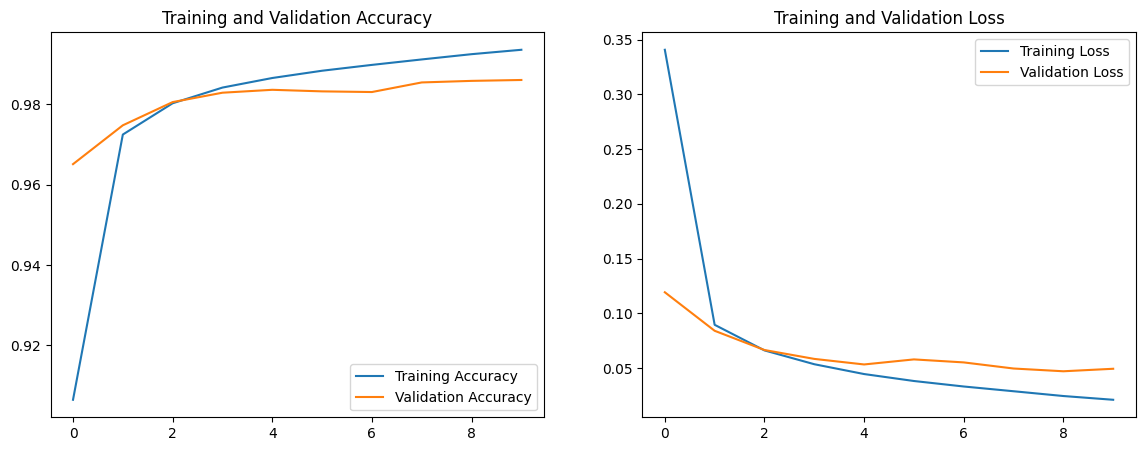

In [68]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')